# Customer Churn Prediction with Machine Learning

## Project Overview

Customer churn is a major challenge for telecommunications companies. Predicting which customers are likely to leave can help organizations design targeted retention strategies and reduce customer attrition.

In this project, several machine learning classification algorithms are developed and compared to predict customer churn using customer demographic, service, contract and billing information.

The main models evaluated are:

- Logistic Regression
- Random Forest
- XGBoost

Model performance is evaluated using ROC-AUC as the primary metric, together with PR-AUC, precision, recall and F1-score.

The analysis also includes cross-validation, hyperparameter optimization, probability threshold optimization and SHAP-based model interpretability.

## Objectives

1. Understand the main characteristics of the customer dataset.
2. Identify variables associated with customer churn.
3. Build and compare several classification models.
4. Optimize the best-performing model.
5. Evaluate its performance on an untouched test set.
6. Optimize the classification threshold according to predictive performance.
7. Interpret the model and identify the main drivers of customer churn.

# 1. Environment and Reproducibility

This section defines the libraries, random seed and general configuration used throughout the analysis.

A fixed random seed is used to ensure that the experiments are reproducible.

In [54]:
# Celda de carga de datos - VERSIÓN PROFESIONAL CON FALLBACK
from pathlib import Path
import pandas as pd

def load_data():
    """
    Carga el dataset de Telco Customer Churn.
    Prioriza archivo local; si no existe, descarga desde Kaggle.
    """
    local_path = Path("data/telco_customer_churn.csv")
    
    if local_path.exists():
        print("📂 Cargando datos desde archivo local...")
        df = pd.read_csv(local_path)
        print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
        return df
    
    print("📥 Descargando dataset desde Kaggle...")
    try:
        import kagglehub
        path = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csv_files = list(Path(path).rglob("*.csv"))
        # Buscar el archivo principal
        for file in csv_files:
            if "WA_Fn-UseC_-Telco-Customer-Churn" in file.name:
                df = pd.read_csv(file)
                break
        else:
            df = pd.read_csv(csv_files[0])
        # Guardar localmente
        local_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(local_path, index=False)
        print(f"✅ Dataset descargado y guardado en: {local_path}")
        return df
    except Exception as e:
        raise RuntimeError(f"❌ Error al cargar los datos: {e}")

df = load_data()
df.head()

📥 Descargando dataset desde Kaggle...
✅ Dataset descargado y guardado en: data/telco_customer_churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Dataset

The dataset used in this project is the Telco Customer Churn dataset.

It contains information about telecommunications customers, including demographic characteristics, subscribed services, contract information, tenure and billing information.

The target variable is `Churn`, which indicates whether a customer left the company.

path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print(f"Dataset downloaded to: {path}")

In [3]:
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print("Dataset downloaded successfully.")
print(f"Path: {path}")

csv_files = list(Path(path).rglob("*.csv"))

print(f"CSV files found: {len(csv_files)}")

for file in csv_files:

    print(f" - {file.name}")



Dataset downloaded successfully.
Path: /Users/alejandromaduenogalvez/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
CSV files found: 1
 - WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
DATA_FILE = csv_files[0]

df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2.1 Dataset Dimensions

Before performing any preprocessing, we inspect the number of observations and variables in the dataset.

In [5]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Variable Description

The main variables in the dataset describe customer demographics, services, contracts and billing characteristics.

| Variable | Description |
|---|---|
| `customerID` | Unique customer identifier |
| `gender` | Customer gender |
| `SeniorCitizen` | Whether the customer is a senior citizen |
| `Partner` | Whether the customer has a partner |
| `Dependents` | Whether the customer has dependents |
| `tenure` | Number of months the customer has been with the company |
| `PhoneService` | Whether the customer has phone service |
| `InternetService` | Type of internet service |
| `Contract` | Customer contract type |
| `PaymentMethod` | Customer payment method |
| `MonthlyCharges` | Monthly customer charges |
| `TotalCharges` | Total customer charges |
| `Churn` | Whether the customer churned |

# 3. Data Quality

Before modelling, the dataset is inspected for missing values, duplicated observations, incorrect data types and other potential data quality issues.

In [6]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percentage": df.isna().mean() * 100
})

missing.sort_values("missing", ascending=False)

,missing,percentage
customerID,0,0.0
DeviceProtection,0,0.0
TotalCharges,0,0.0
MonthlyCharges,0,0.0
PaymentMethod,0,0.0
PaperlessBilling,0,0.0
Contract,0,0.0
StreamingMovies,0,0.0
StreamingTV,0,0.0
TechSupport,0,0.0


In [7]:
empty_total_charges = df[
    df["TotalCharges"].astype(str).str.strip() == ""
]

print(
    f"Empty TotalCharges values: "
    f"{len(empty_total_charges)}"
)

Empty TotalCharges values: 11


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print(

    f"Missing TotalCharges after conversion: "

    f"{df['TotalCharges'].isna().sum()}"

)

Missing TotalCharges after conversion: 11


In [10]:
def data_quality_report(data):
    report = pd.DataFrame({
        "dtype": data.dtypes,
        "missing": data.isna().sum(),
        "missing_pct": data.isna().mean() * 100,
        "unique": data.nunique()
    })

    return report.sort_values(
        "missing_pct",
        ascending=False
    )


data_quality_report(df)

,dtype,missing,missing_pct,unique
TotalCharges,float64,11,0.156183,6530
customerID,object,0,0.000000,7043
DeviceProtection,object,0,0.000000,3
MonthlyCharges,float64,0,0.000000,1585
PaymentMethod,object,0,0.000000,4
PaperlessBilling,object,0,0.000000,2
Contract,object,0,0.000000,3
StreamingMovies,object,0,0.000000,3
StreamingTV,object,0,0.000000,3
TechSupport,object,0,0.000000,3


# 4. Exploratory Data Analysis

## 4.1 Target Variable

The first step of the exploratory analysis is to examine the distribution of the target variable.

Understanding the class distribution is particularly important because customer churn is not evenly distributed across the two classes.

In [11]:
target_counts = df["Churn"].value_counts()

target_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


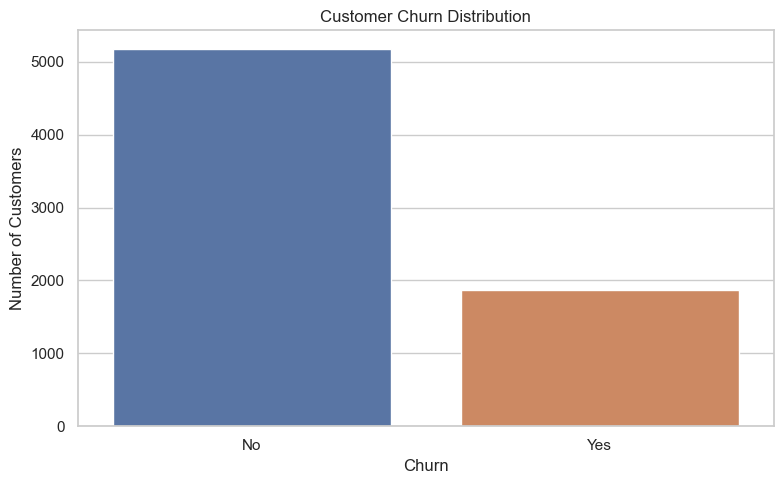

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 4.2 Numerical Variables

The main numerical variables are:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`

Their distributions are examined both globally and according to churn status.

In [13]:
numeric_features = [

    "tenure",

    "MonthlyCharges",

    "TotalCharges"

]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


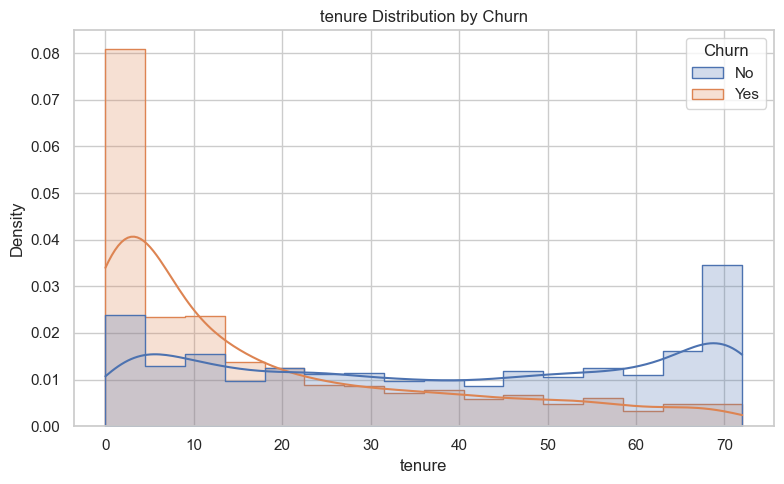

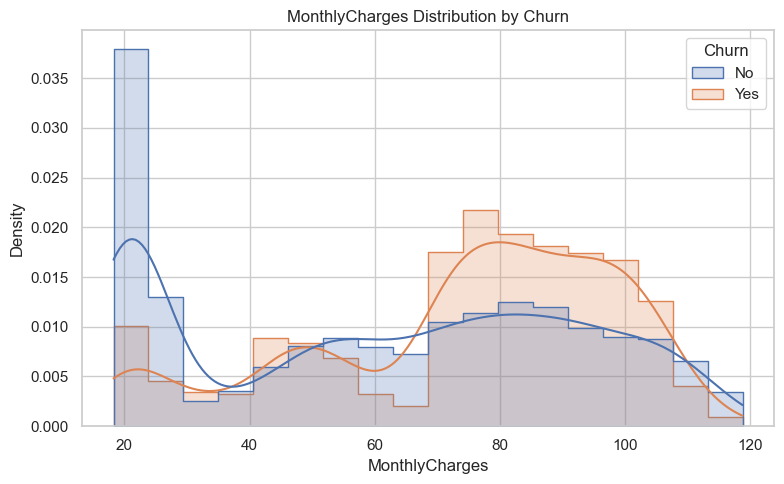

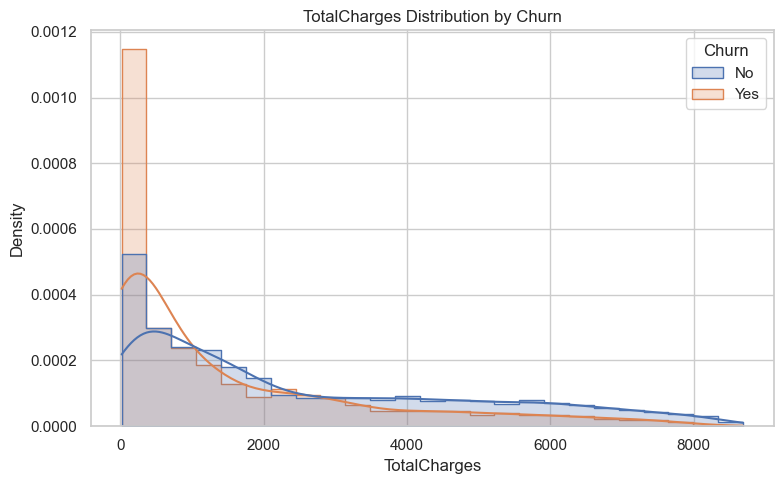

In [14]:
for feature in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Churn",
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{feature} Distribution by Churn")
    plt.tight_layout()
    plt.show()

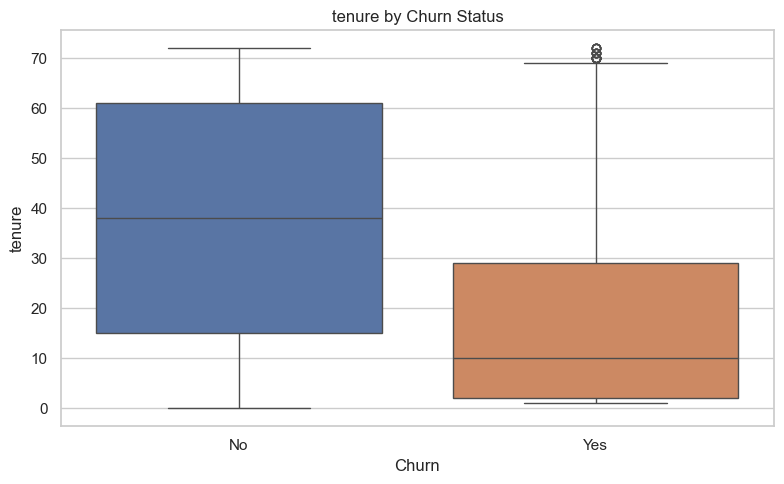

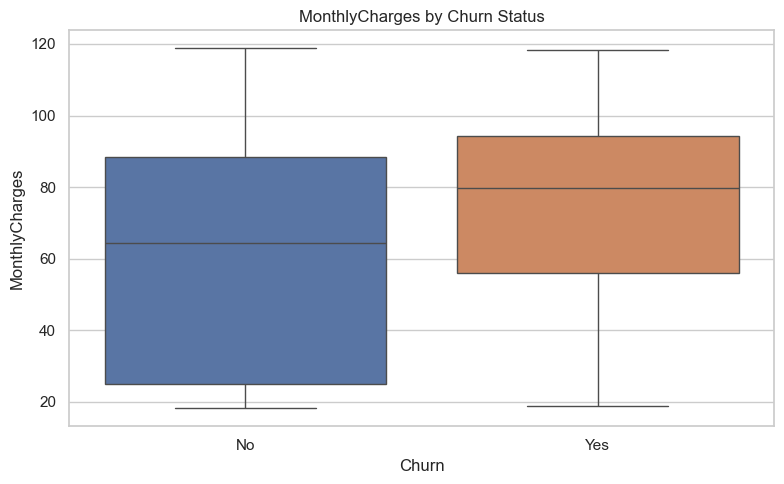

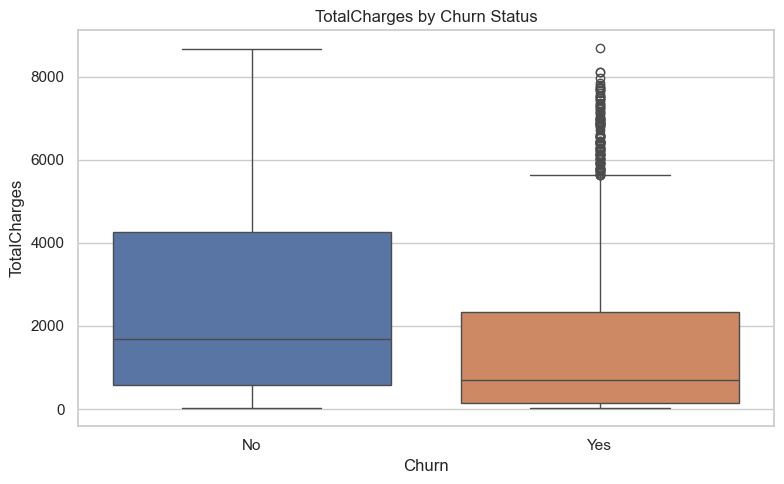

In [15]:
for feature in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        hue="Churn",
        legend=False
    )

    plt.title(f"{feature} by Churn Status")
    plt.tight_layout()
    plt.show()

## 4.3 Categorical Variables

Categorical variables are examined in relation to customer churn.

Rather than only examining the frequency of each category, churn rates are calculated within each category. This provides a more meaningful interpretation of the relationship between customer characteristics and churn.

In [16]:
categorical_features = [

    col for col in df.select_dtypes(include=["object"]).columns

    if col not in ["customerID", "Churn"]

]

print(f"Número de variables categóricas: {len(categorical_features)}")

print(categorical_features)

Número de variables categóricas: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
for feature in categorical_features:

    churn_rate = (
        df.groupby(feature, observed=True)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{feature}")
    display(
        churn_rate
        .rename("Churn Rate (%)")
        .to_frame()
    )


gender


,Churn Rate (%)
gender,
Female,26.920872
Male,26.160338



Partner


,Churn Rate (%)
Partner,
No,32.957979
Yes,19.664903



Dependents


...

,Churn Rate (%)
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858



PaperlessBilling


,Churn Rate (%)
PaperlessBilling,
Yes,33.565092
No,16.330084



PaymentMethod


,Churn Rate (%)
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


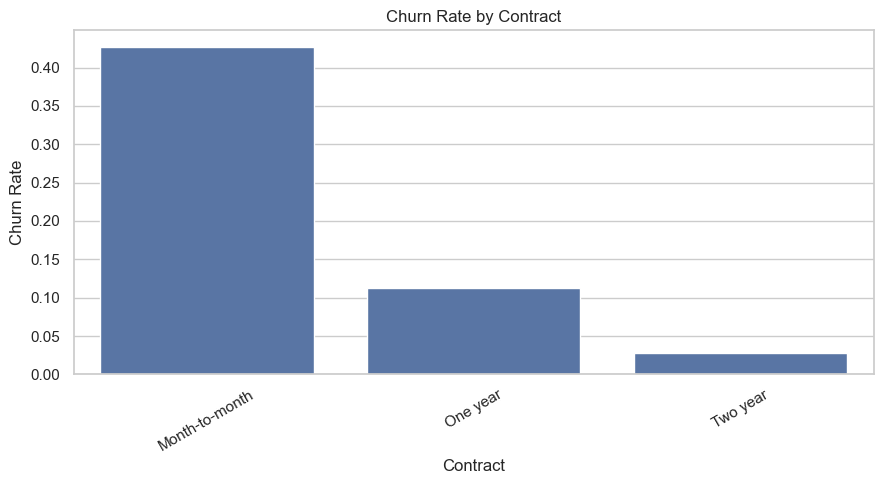

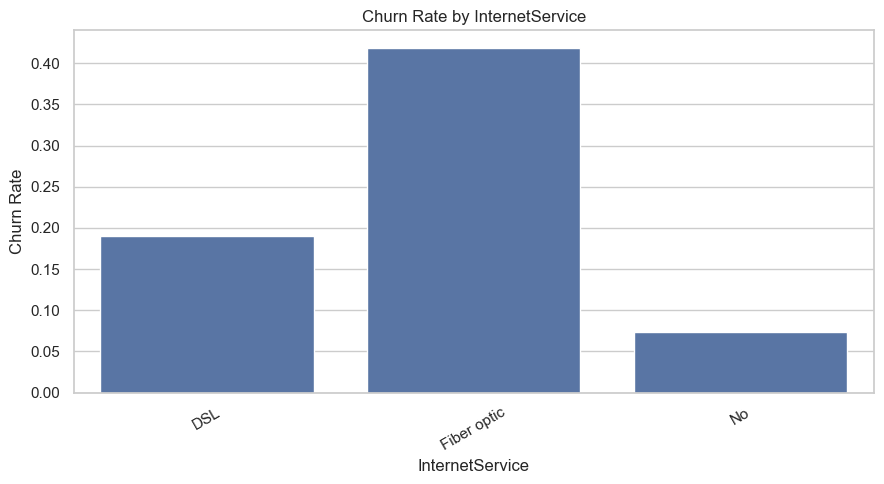

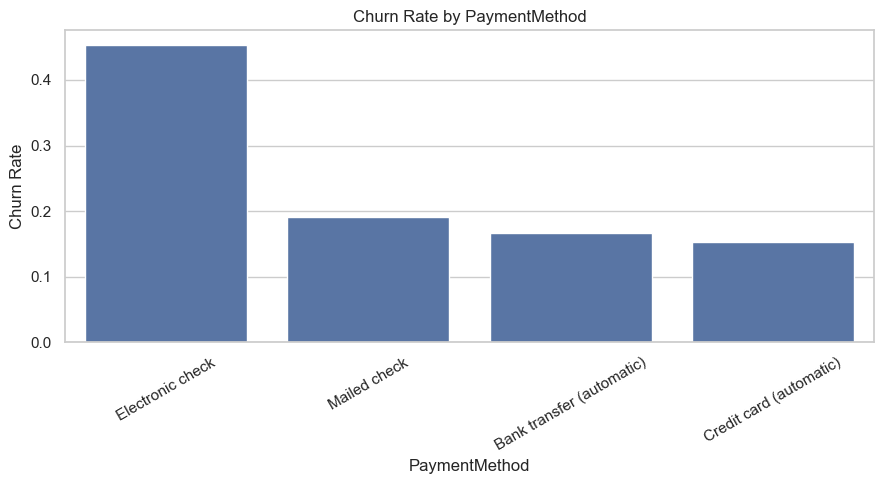

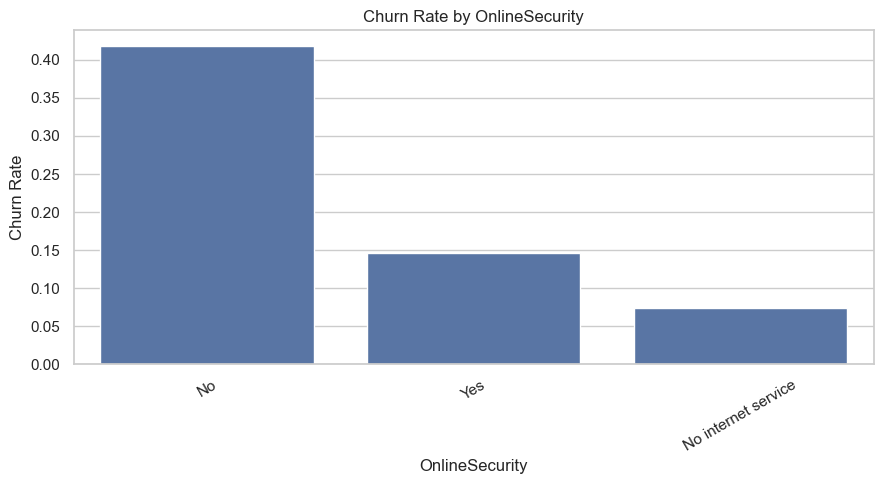

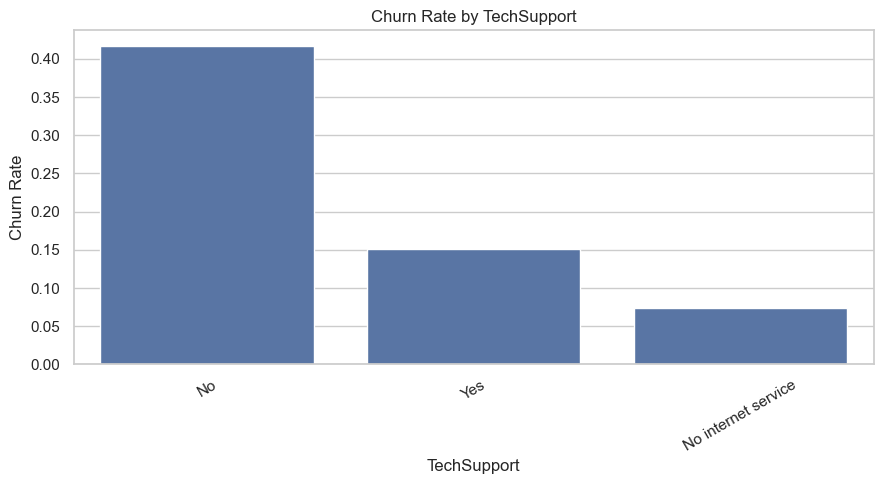

In [18]:
selected_categorical = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport"
]

for feature in selected_categorical:

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=df,
        x=feature,
        y=(df["Churn"] == "Yes").astype(int),
        errorbar=None
    )

    plt.title(f"Churn Rate by {feature}")
    plt.ylabel("Churn Rate")
    plt.xlabel(feature)

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

## 4.4 Numerical Correlations

Correlation analysis is used to identify potential relationships among numerical variables.

This analysis is descriptive and is not used to select variables before cross-validation.

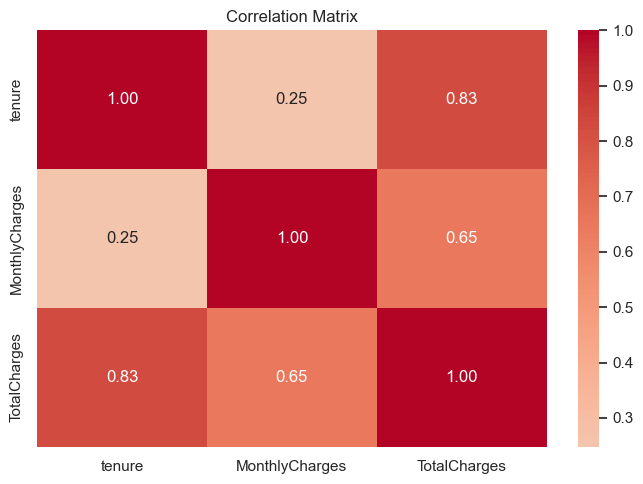

In [19]:
corr = df[numeric_features].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 5. Feature Definition

The customer identifier is removed because it is an identifier rather than a predictive characteristic.

The target variable is encoded as:

- `0` → No churn
- `1` → Churn

In [20]:
X = df.drop(
    columns=["Churn", "customerID"]
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(f"Features: {X.shape[1]}")
print(f"Observations: {X.shape[0]}")

Features: 19
Observations: 7043


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5634, 19)
Test set: (1409, 19)

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# 7. Preprocessing Pipeline

Preprocessing is implemented using a scikit-learn `ColumnTransformer` and `Pipeline`.

This ensures that preprocessing operations are learned only from the training data within each cross-validation fold, preventing data leakage.

Numerical variables are median-imputed and standardized.

Categorical variables are imputed using the most frequent category and one-hot encoded.

In [22]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

In [23]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

# 8. Baseline Model

Before fitting machine learning models, a Dummy Classifier is used as a baseline.

This provides a reference point to determine whether the predictive models learn useful patterns beyond simply predicting the majority class.

In [24]:
baseline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DummyClassifier(
            strategy="most_frequent"
        )
    )
])

# 9. Cross-Validation Strategy

Model development is evaluated using stratified repeated cross-validation.

Five folds and three repetitions are used, resulting in 15 validation folds.

Stratification preserves the proportion of churned and non-churned customers in each fold.

In [25]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

In [26]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# 10. Model Development

## 10.1 Logistic Regression

Logistic Regression is used as an interpretable linear baseline for the classification problem.

In [27]:
logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

## 10.2 Random Forest

Random Forest is a nonlinear ensemble method based on multiple decision trees.

In [28]:
rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

## 10.3 XGBoost

XGBoost is a gradient boosting algorithm based on decision trees.

It is evaluated as the main high-performance candidate because of its ability to model nonlinear relationships and interactions between predictors.

In [29]:
xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [30]:
models = {
    "Baseline": baseline,
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

model_results = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
)

model_results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.843935,0.654457,0.802094,0.652501,0.544705,0.593590
2,Random Forest,0.822905,0.619264,0.787303,0.630726,0.479376,0.544334
3,XGBoost,0.820274,0.618399,0.784050,0.611050,0.512598,0.557383
0,Baseline,0.500000,0.265353,0.734647,0.000000,0.000000,0.000000


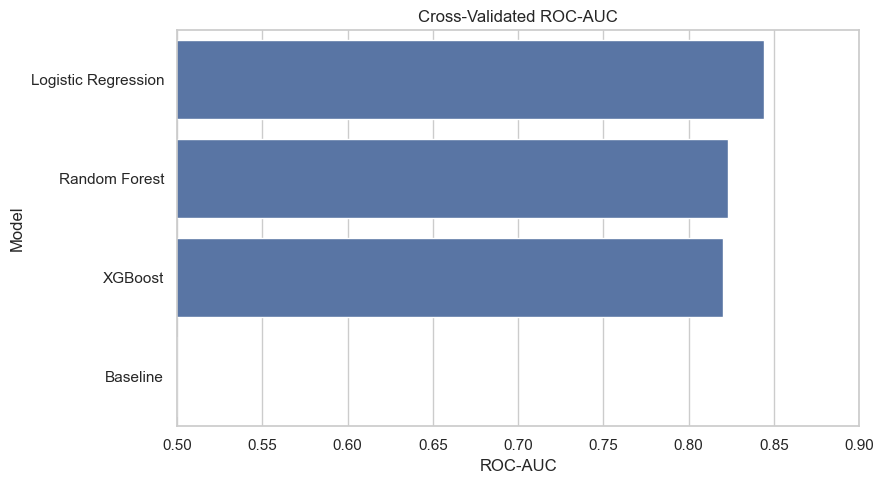

In [31]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="ROC-AUC",
    y="Model"
)

plt.title("Cross-Validated ROC-AUC")
plt.xlim(0.5, 0.9)

plt.tight_layout()
plt.show()

# 11. Hyperparameter Optimization

The best-performing models are further optimized using randomized hyperparameter search.

The optimization is performed exclusively on the training set using repeated cross-validation.

ROC-AUC is used as the optimization metric.

In [32]:
xgb_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [33]:
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "classifier__gamma": [0, 0.05, 0.1, 0.2],
    "classifier__reg_alpha": [0, 0.01, 0.1],
    "classifier__reg_lambda": [1, 5, 10, 20]
}

In [34]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=4983, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strat...
                                        'classifier__gamma': [0, 0.05, 0.1,
                                                              0.2],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [2, 3, 4, 5],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__reg_alpha': [0, 0.01, 0.1],
                                        'classifier__reg_lambda': [1, 5, 10,
                                                                   20],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=4983, scoring='roc_auc', verbose=1)

In [35]:
print("Best ROC-AUC:")
print(xgb_search.best_score_)

print("\nBest parameters:")

for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

Best ROC-AUC:
0.8486848255749561

Best parameters:
classifier__subsample: 0.7
classifier__reg_lambda: 1
classifier__reg_alpha: 0.01
classifier__n_estimators: 200
classifier__min_child_weight: 1
classifier__max_depth: 2
classifier__learning_rate: 0.05
classifier__gamma: 0.1
classifier__colsample_bytree: 0.6


# 12. Final Model

The optimized XGBoost pipeline is selected as the final candidate model.

Importantly, the test set has not been used during model selection or hyperparameter optimization.

In [36]:
final_model = xgb_search.best_estimator_

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Senior...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [37]:
y_test_proba = final_model.predict_proba(
    X_test
)[:, 1]

In [38]:
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC:  {test_pr_auc:.4f}")

Test ROC-AUC: 0.8476
Test PR-AUC:  0.6462


In [39]:
y_test_pred_050 = (
    y_test_proba >= 0.50
).astype(int)

print(
    classification_report(
        y_test,
        y_test_pred_050,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



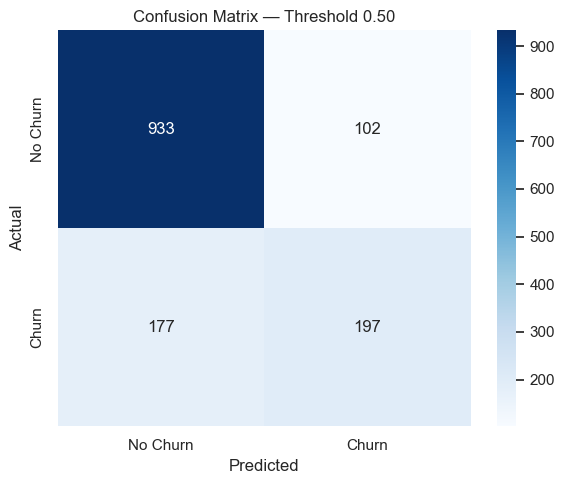

In [40]:
cm = confusion_matrix(
    y_test,
    y_test_pred_050
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Threshold 0.50")

plt.tight_layout()
plt.show()

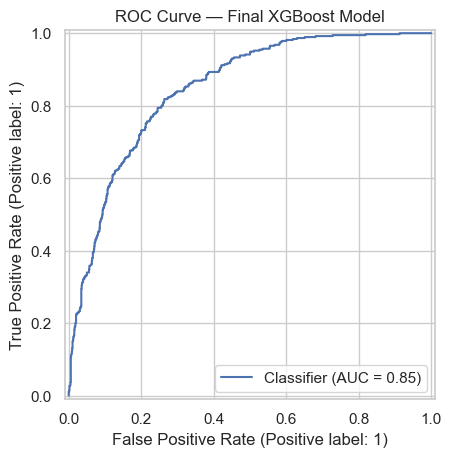

In [41]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("ROC Curve — Final XGBoost Model")
plt.show()

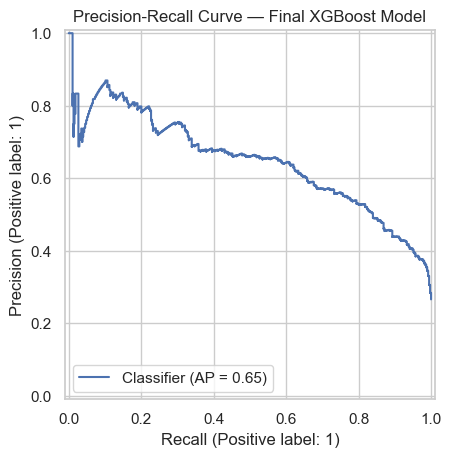

In [42]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title(
    "Precision-Recall Curve — Final XGBoost Model"
)

plt.show()

# 13. Classification Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for customer churn prediction.

Because identifying potential churners is important for retention strategies, different probability thresholds are evaluated.

The F1-score is used as the main criterion for threshold selection because it balances precision and recall.

In [43]:
oof_proba = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [44]:
thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        oof_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_train,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            y_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
21,0.31,0.548916,0.761873,0.638095
23,0.33,0.559857,0.735117,0.635628
22,0.32,0.552906,0.744482,0.634550
20,0.30,0.540490,0.767893,0.634429
24,0.34,0.564103,0.721070,0.633001
28,0.38,0.594356,0.676254,0.632666
19,0.29,0.533548,0.776589,0.632525
27,0.37,0.586720,0.685619,0.632326
26,0.36,0.577839,0.697659,0.632121
25,0.35,0.570811,0.706355,0.631390


In [45]:
best_threshold_row = (
    threshold_results
    .loc[
        threshold_results["f1"].idxmax()
    ]
)

optimal_threshold = (
    best_threshold_row["threshold"]
)

print(
    f"Optimal threshold: "
    f"{optimal_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['recall']:.4f}"
)

print(
    f"F1: "
    f"{best_threshold_row['f1']:.4f}"
)

Optimal threshold: 0.31
Precision: 0.5489
Recall: 0.7619
F1: 0.6381


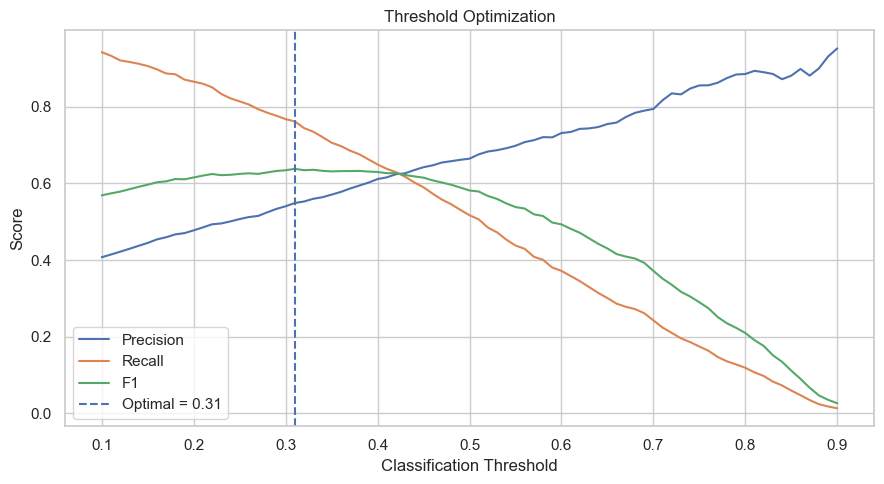

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal = {optimal_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()

plt.tight_layout()
plt.show()

In [47]:
y_test_pred_optimal = (
    y_test_proba >= optimal_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_test_pred_optimal,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.78      0.84      1035
       Churn       0.56      0.76      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



In [48]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1"
    ],
    "Threshold 0.50": [
        precision_score(
            y_test,
            y_test_pred_050
        ),
        recall_score(
            y_test,
            y_test_pred_050
        ),
        f1_score(
            y_test,
            y_test_pred_050
        )
    ],
    f"Threshold {optimal_threshold:.2f}": [
        precision_score(
            y_test,
            y_test_pred_optimal
        ),
        recall_score(
            y_test,
            y_test_pred_optimal
        ),
        f1_score(
            y_test,
            y_test_pred_optimal
        )
    ]
})

threshold_comparison

,Metric,Threshold 0.50,Threshold 0.31
0,Precision,0.658863,0.558185
1,Recall,0.526738,0.756684
2,F1,0.585438,0.642452


# 14. Model Interpretability

Predictive performance alone is not sufficient to understand customer churn.

SHAP (SHapley Additive exPlanations) is used to investigate how individual features contribute to the model's predictions.

The analysis focuses on global feature importance and the direction of feature effects.

In [49]:
trained_preprocessor = (
    final_model
    .named_steps["preprocessor"]
)

trained_xgb = (
    final_model
    .named_steps["classifier"]
)

X_train_transformed = (
    trained_preprocessor
    .transform(X_train)
)

feature_names = (
    trained_preprocessor
    .get_feature_names_out()
)

In [50]:
explainer = shap.TreeExplainer(
    trained_xgb
)

shap_values = explainer(
    X_train_transformed
)

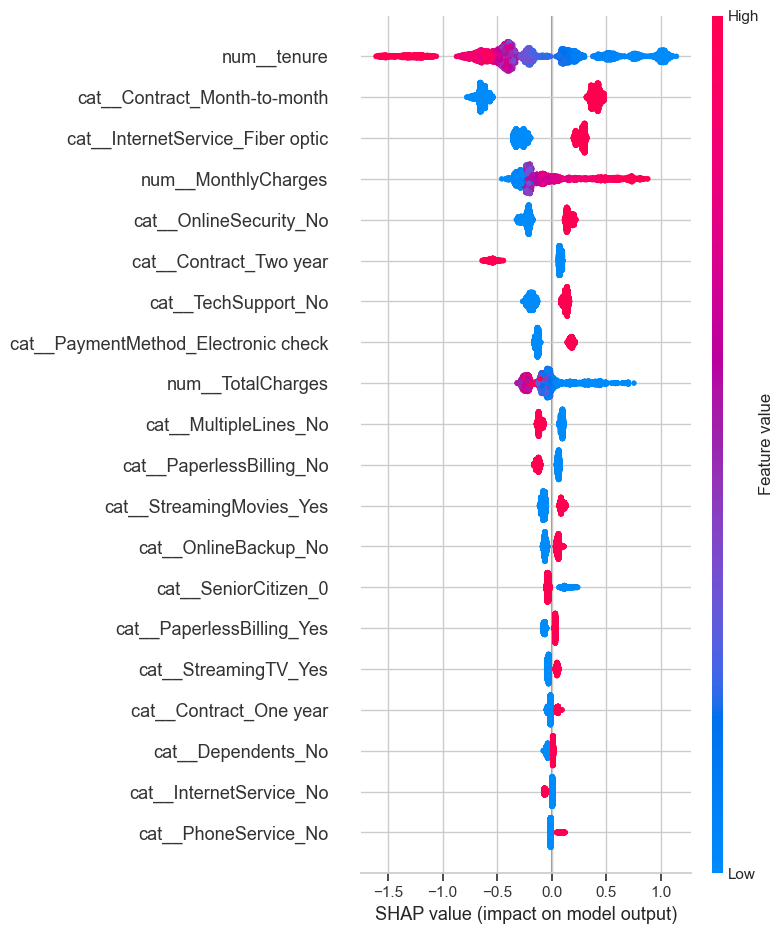

In [51]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

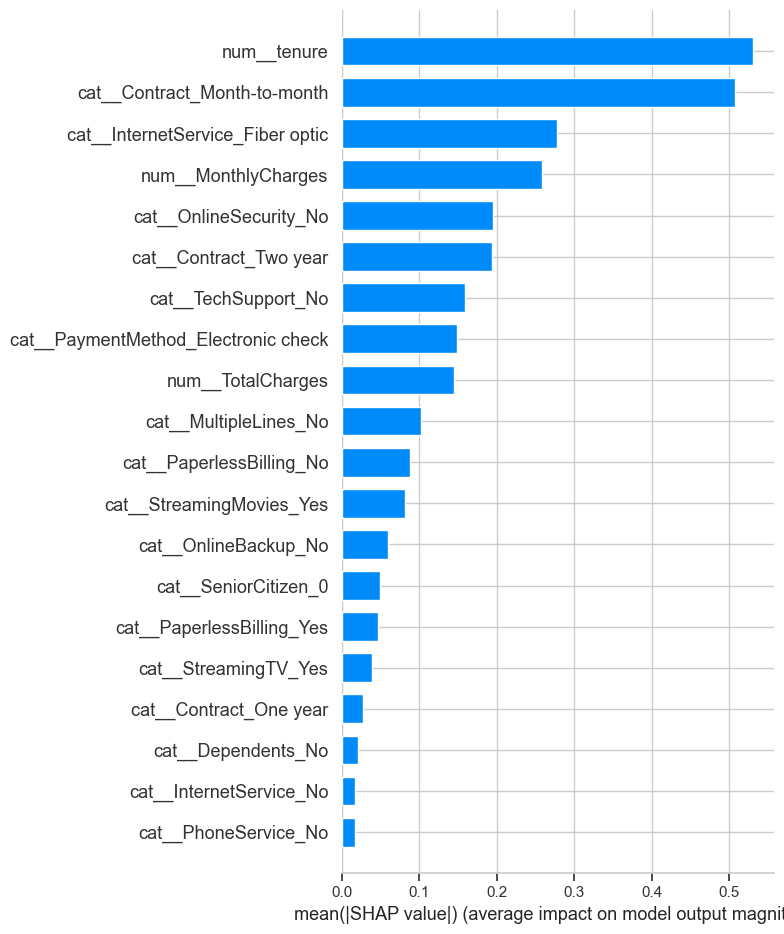

In [52]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

# 15. Business Insights

The SHAP analysis provides an interpretable view of how the final XGBoost model
uses customer characteristics to estimate churn risk.

SHAP values quantify the contribution of each feature to an individual
prediction. Positive SHAP values increase the model's predicted churn risk,
whereas negative values decrease it. The color indicates the feature value:
red represents high values or the presence of a one-hot encoded category,
while blue represents low values or the absence of that category.

These results describe patterns learned by the predictive model and should
therefore be interpreted as predictive associations rather than causal effects.

---

## 15.1 Main Churn Drivers

### 1. Customer Tenure

`num__tenure` is by far the most influential feature in the model.

The SHAP distribution shows a clear and strong relationship between tenure and
predicted churn risk. Low tenure values (blue) are predominantly associated
with positive SHAP values, increasing the model's estimated probability of
churn. In contrast, high tenure values (red) are associated with strongly
negative SHAP values.

The magnitude of this effect is particularly notable, with SHAP values for
low-tenure customers extending substantially into positive territory, while
high-tenure observations can produce strongly negative contributions.

**Business interpretation:**  
The model identifies newly acquired customers as the highest-priority segment
for churn prevention. The first months of the customer relationship appear to
represent a particularly important period for retention.

**Potential action:**  
Implement proactive onboarding, early satisfaction monitoring and targeted
retention campaigns during the initial stages of the customer lifecycle.

---

### 2. Contract Type

Contract structure is the second most influential group of predictors,
particularly the distinction between month-to-month and long-term contracts.

For:

`cat__Contract_Month-to-month`

the presence of the category (red) is associated with positive SHAP values,
while its absence (blue) is associated with negative SHAP values.

The opposite pattern is observed for:

`cat__Contract_Two year`

where the presence of the category is associated with negative SHAP values.

This indicates that the model strongly differentiates customers according to
their contractual commitment.

**Business interpretation:**  
Month-to-month customers represent a substantially higher predicted churn-risk
segment, whereas customers with two-year contracts tend to receive lower
predicted churn probabilities.

**Potential action:**  
Month-to-month customers could be prioritized for retention campaigns and,
where commercially appropriate, incentives encouraging longer-term
commitments.

---

### 3. Internet Service and Monthly Charges

`cat__InternetService_Fiber optic` and `num__MonthlyCharges` are among the next
most influential predictors.

For `cat__InternetService_Fiber optic`, the presence of fiber-optic service
(red) is associated with positive SHAP values, whereas its absence (blue)
generally contributes negatively.

Similarly, higher values of `MonthlyCharges` (red) tend to produce positive
SHAP values, while lower monthly charges are generally associated with lower
predicted churn risk.

The two variables therefore provide complementary information about the
customer's service and pricing profile.

**Business interpretation:**  
Customers with fiber-optic service and relatively high monthly charges are
more frequently identified by the model as higher-risk customers.

This does not imply that fiber-optic service or higher prices cause churn.
The model is identifying an association between these characteristics and
observed churn outcomes.

**Potential action:**  
High-charge customers could be monitored more closely, particularly when they
also exhibit other risk indicators such as short tenure or month-to-month
contracts. Pricing, perceived value and service quality could be investigated
within this segment.

---

### 4. Online Security and Technical Support

Two additional variables with clear SHAP patterns are:

- `cat__OnlineSecurity_No`
- `cat__TechSupport_No`

For both variables, the presence of the `_No` category (red) generally pushes
the prediction towards higher churn risk, whereas its absence (blue) tends to
reduce the predicted risk.

This indicates that customers without Online Security or Technical Support
are more frequently classified by the model as higher-risk customers.

**Business interpretation:**  
The absence of additional support and security services is an important
characteristic of higher-risk customer profiles.

**Potential action:**  
Personalized offers for security and technical support services could be
considered as part of retention strategies, particularly when combined with
other high-risk characteristics.

---

### 5. Payment Method

`cat__PaymentMethod_Electronic check` is another relevant categorical
predictor.

Customers using electronic check payments (red) tend to have positive SHAP
values, while customers without this payment method (blue) generally have
negative contributions.

Although its overall impact is smaller than tenure or contract type, the
pattern is relatively clear.

**Business interpretation:**  
Electronic-check customers represent another identifiable segment with
elevated predicted churn risk.

**Potential action:**  
This segment could be monitored in combination with contractual and service
characteristics rather than being targeted solely on payment method.

---

## 15.2 Additional Model Patterns

### Total Charges

`num__TotalCharges` shows an interesting pattern that complements the effect
of tenure.

Higher TotalCharges values (red) tend to be associated with negative SHAP
values, whereas lower values (blue) can contribute positively to churn risk.

This is consistent with the strong influence of tenure: customers who have
remained with the company for longer periods naturally tend to accumulate
higher total charges.

Therefore, TotalCharges should not be interpreted independently as evidence
that higher cumulative spending reduces churn. Its predictive contribution
is likely related to the broader customer lifecycle represented by the
variable.

---

### Senior Citizen Status

The feature:

`cat__SeniorCitizen_0`

also shows a meaningful directional pattern.

Because this is a one-hot encoded variable, a high feature value indicates
that the customer belongs to the `SeniorCitizen = 0` category.

The plot shows that the presence of this category tends to contribute
negatively to the prediction, while its absence is associated with a
positive contribution.

Consequently, the model assigns somewhat higher predicted churn risk to
senior customers than to non-senior customers, although the magnitude of
this effect is considerably smaller than that of tenure or contract type.

---

### Other Service Characteristics

Several additional variables exhibit smaller but still detectable effects:

- `cat__MultipleLines_No`
- `cat__PaperlessBilling_No`
- `cat__StreamingMovies_Yes`
- `cat__OnlineBackup_No`
- `cat__StreamingTV_Yes`
- `cat__Contract_One year`
- `cat__Dependents_No`
- `cat__InternetService_No`
- `cat__PhoneService_No`

Their SHAP distributions are concentrated closer to zero, indicating that
their individual contributions are generally weaker than the main predictors.

Nevertheless, these variables can provide useful incremental information when
combined with the strongest predictors.

---

# 15.3 Overall Customer Risk Profile

The SHAP analysis suggests that churn risk is not determined by a single
characteristic. Instead, the model identifies combinations of customer
attributes that collectively increase or decrease predicted churn probability.

A particularly relevant high-risk profile combines several characteristics
observed in the SHAP analysis:

- Short customer tenure
- Month-to-month contract
- Fiber-optic internet service
- Higher monthly charges
- No Online Security
- No Technical Support
- Electronic-check payment method

The presence of several of these characteristics simultaneously can result
in a substantially higher predicted churn probability.

Importantly, these characteristics should not be interpreted as deterministic
rules. A customer matching this profile is not necessarily going to churn;
rather, the profile represents a combination of characteristics that the
model associates with higher predicted risk.

---

# 15.4 Retention Strategy

The predictive model can be incorporated into a risk-based customer retention
framework.

A potential workflow is:

1. Generate a churn probability for each active customer.
2. Rank customers according to predicted churn risk.
3. Identify the highest-risk customer segments.
4. Combine churn probability with customer value or expected lifetime value.
5. Apply targeted retention interventions.
6. Monitor subsequent customer behavior and campaign effectiveness.

This approach allows retention resources to be allocated according to both
predicted risk and potential business value.

For example, a high-value customer with a high predicted churn probability
could receive a more intensive retention intervention than a low-value
customer with the same predicted risk.

---

# 15.5 Classification Threshold and Business Costs

The probability threshold determines which customers are ultimately classified
as potential churners.

The default threshold of 0.50 is not necessarily optimal for a retention
strategy. A lower threshold identifies a larger proportion of potentially
at-risk customers, increasing recall but also generating more false positives.

Conversely, a higher threshold produces a more selective intervention
strategy, increasing precision at the cost of potentially missing some
customers who will eventually churn.

Therefore, threshold selection should ultimately reflect the economic costs
associated with different prediction errors.

In a real-world deployment, the optimal threshold should ideally be determined
using:

- Cost of contacting a customer
- Cost of retention incentives
- Customer lifetime value
- Cost of losing a customer
- Expected success rate of retention interventions

This would allow the classification threshold to be optimized according to
business value rather than solely according to a statistical metric such as
F1-score.

---

# 15.6 Key Takeaways

The SHAP analysis highlights several important patterns in the model:

| Feature | SHAP pattern | Interpretation |
|---|---|---|
| `tenure` | Low values → positive SHAP; high values → negative SHAP | Newer customers have higher predicted churn risk |
| `Contract_Month-to-month` | Present → positive SHAP | Month-to-month customers have higher predicted risk |
| `Contract_Two year` | Present → negative SHAP | Two-year customers have lower predicted risk |
| `InternetService_Fiber optic` | Present → positive SHAP | Fiber customers receive higher predicted risk |
| `MonthlyCharges` | High values → positive SHAP | Higher monthly charges contribute to higher predicted risk |
| `OnlineSecurity_No` | Present → positive SHAP | Lack of online security contributes to higher predicted risk |
| `TechSupport_No` | Present → positive SHAP | Lack of technical support contributes to higher predicted risk |
| `PaymentMethod_Electronic check` | Present → positive SHAP | Electronic-check customers have higher predicted risk |
| `TotalCharges` | High values → negative SHAP | Higher cumulative charges are associated with lower predicted risk, likely reflecting customer tenure |
| `SeniorCitizen_0` | Present → negative SHAP | Non-senior customers receive lower predicted risk than senior customers |

Overall, the strongest predictive signal comes from customer tenure, followed
by contractual commitment, internet service type and monthly charges.

The model therefore suggests that the most relevant retention opportunity is
not simply to target customers with the highest predicted probability of
churn, but to identify the combination of customer lifecycle, contractual
commitment and service characteristics associated with elevated risk.

This provides a bridge between predictive modelling and actionable customer
retention strategies.

# 16. Final Results

The final XGBoost model is evaluated on the previously untouched test set.

The main performance metrics are:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1-score

ROC-AUC measures the model's ability to rank churned customers above non-churned customers independently of a specific classification threshold.

The classification threshold is optimized separately when converting predicted probabilities into binary churn predictions.

In [53]:
final_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1"
    ],
    "Test Performance": [
        roc_auc_score(
            y_test,
            y_test_proba
        ),
        average_precision_score(
            y_test,
            y_test_proba
        ),
        precision_score(
            y_test,
            y_test_pred_optimal
        ),
        recall_score(
            y_test,
            y_test_pred_optimal
        ),
        f1_score(
            y_test,
            y_test_pred_optimal
        )
    ]
})

final_results

,Metric,Test Performance
0,ROC-AUC,0.847570
1,PR-AUC,0.646249
2,Precision,0.558185
3,Recall,0.756684
4,F1,0.642452


# 17. Limitations and Future Work

Although the final model provides useful predictive performance, several limitations should be considered.

### Limitations

- The dataset represents a single telecommunications dataset and may not generalize to other companies or markets.
- The analysis is based on observational data and therefore does not establish causal relationships.
- The selected classification threshold depends on the assumed business objective.
- External validation on an independent dataset was not available.

### Future Work

Potential improvements include:

- Probability calibration.
- Cost-sensitive classification based on the economic cost of churn.
- Bayesian or more advanced hyperparameter optimization.
- Comparison with CatBoost and LightGBM.
- External validation using another customer dataset.
- Deployment as an API or interactive dashboard.

# 18. Conclusion

This project developed an end-to-end machine learning pipeline for customer churn prediction.

Several classification algorithms were compared using stratified repeated cross-validation. XGBoost was subsequently optimized through hyperparameter search and evaluated on an untouched test set.

In addition to ranking performance using ROC-AUC and PR-AUC, the classification threshold was optimized to obtain a better balance between precision and recall.

Finally, SHAP was used to interpret the model and identify the variables that contribute most strongly to churn predictions.

The resulting workflow provides not only a predictive model but also an interpretable framework that can support data-driven customer retention strategies.